In [1]:
import pandas as pd
from os import scandir
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [2]:
def show(img, win_name='window'):
    cv.namedWindow(win_name, cv.WINDOW_NORMAL)
    
    while True:
        cv.imshow(win_name, img)
        if cv.waitKey(20) & 0xFF == 27: break
    cv.destroyAllWindows()


def seg(data, n_clusters=10):
    kmeans = KMeans(n_clusters=n_clusters).fit(data)
    raimbow = np.empty((data.shape), dtype=np.uint8)
    for k in range(kmeans.n_clusters):
        idx = np.nonzero(kmeans.labels_ == k)
        raimbow[idx] = np.rint(np.mean(data[idx], axis=0))
    return raimbow
    # raimbow = cv.cvtColor(np.uint8(raimbov.reshape(img.shape)), cv.COLOR_LAB2RGB)

In [95]:
img = cv.imread('data/NV/ISIC_0000018_downsampled.jpg')
Z = img.reshape((-1,3))
 
# convert to np.float32
Z = np.float32(Z)
 
# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
ret,label,center=cv.kmeans(Z,K,None,criteria,10, cv.KMEANS_PP_CENTERS)
 
# Now convert back into uint8, and make original image
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img.shape))

## select darkest region

show(res2,'res2')
show(np.where(np.tile(label.reshape(img.shape[:2])[..., np.newaxis], (1,1,3)) == np.argmin(center[..., 0]), img, np.zeros(img.shape, dtype=np.uint8)))


In [74]:
hold = np.empty((img.shape[0] * img.shape[1], 3), dtype=np.uint8)
idx = np.nonzero(label.flatten() == np.argmin(center[..., 0]))
hold[idx] = center[np.argmin(center[..., 0])] # select darkest blue ?= darkest region
show(np.reshape(hold, img.shape, copy=False))

In [4]:
img = cv.imread('data/MEL/ISIC_0000167.jpg')
RGBimg = cv.cvtColor(img, cv.COLOR_BGR2RGB)
RGBimg_flat = RGBimg.reshape(-1, 3)
LABimg = cv.cvtColor(img, cv.COLOR_BGR2LAB)
LABimg_flat = LABimg.reshape(-1, 3)

In [5]:
show(img)

In [4]:
def seg(data, n_clusters=10):
    kmeans = KMeans(n_clusters=n_clusters).fit(data)
    raimbow = np.empty((data.shape), dtype=np.uint8)
    for k in range(kmeans.n_clusters):
        idx = np.nonzero(kmeans.labels_ == k)
        raimbow[idx] = np.rint(np.mean(data[idx], axis=0))
    return raimbow
    # raimbow = cv.cvtColor(np.uint8(raimbov.reshape(img.shape)), cv.COLOR_LAB2RGB)

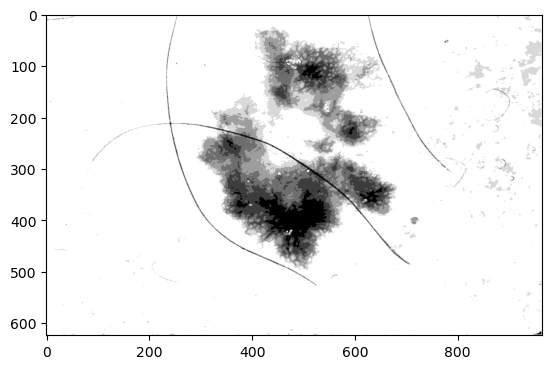

In [5]:
cl = seg(LABimg[..., 0].reshape(-1, 1)).reshape(LABimg[...,0].shape)
plt.imshow(np.clip(cl, np.unique(cl)[0], np.unique(cl)[5]), cmap='gray')
plt.show()

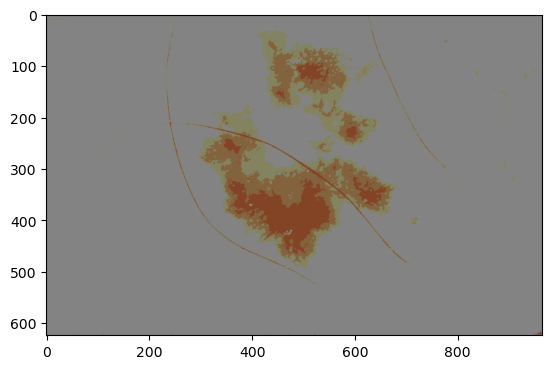

In [9]:
cl = seg(LABimg.reshape(-1, 3)).reshape(LABimg.shape)
cl = cv.cvtColor(cl, cv.COLOR_LAB2RGB)
plt.imshow(np.clip(cl, np.unique(cl)[0], np.unique(cl)[5]))
plt.show()

In [9]:
kmeans = KMeans(n_clusters=10).fit(LABimg_flat)
raimbov = np.empty((LABimg_flat.shape))
for k in range(kmeans.n_clusters):
    idx = np.nonzero(kmeans.labels_ == k)
    raimbov[idx] = np.rint(np.mean(LABimg_flat[idx], axis=0))
raimbov = cv.cvtColor(np.uint8(raimbov.reshape(img.shape)), cv.COLOR_LAB2RGB)

In [11]:
Rkmeans = KMeans(n_clusters=10).fit(RGBimg_flat)
Rraimbov = np.empty((RGBimg_flat.shape))
for k in range(Rkmeans.n_clusters):
    idx = np.nonzero(Rkmeans.labels_ == k)
    Rraimbov[idx] = np.rint(np.mean(RGBimg_flat[idx], axis=0))
Rraimbov = np.uint8(Rraimbov.reshape(img.shape))

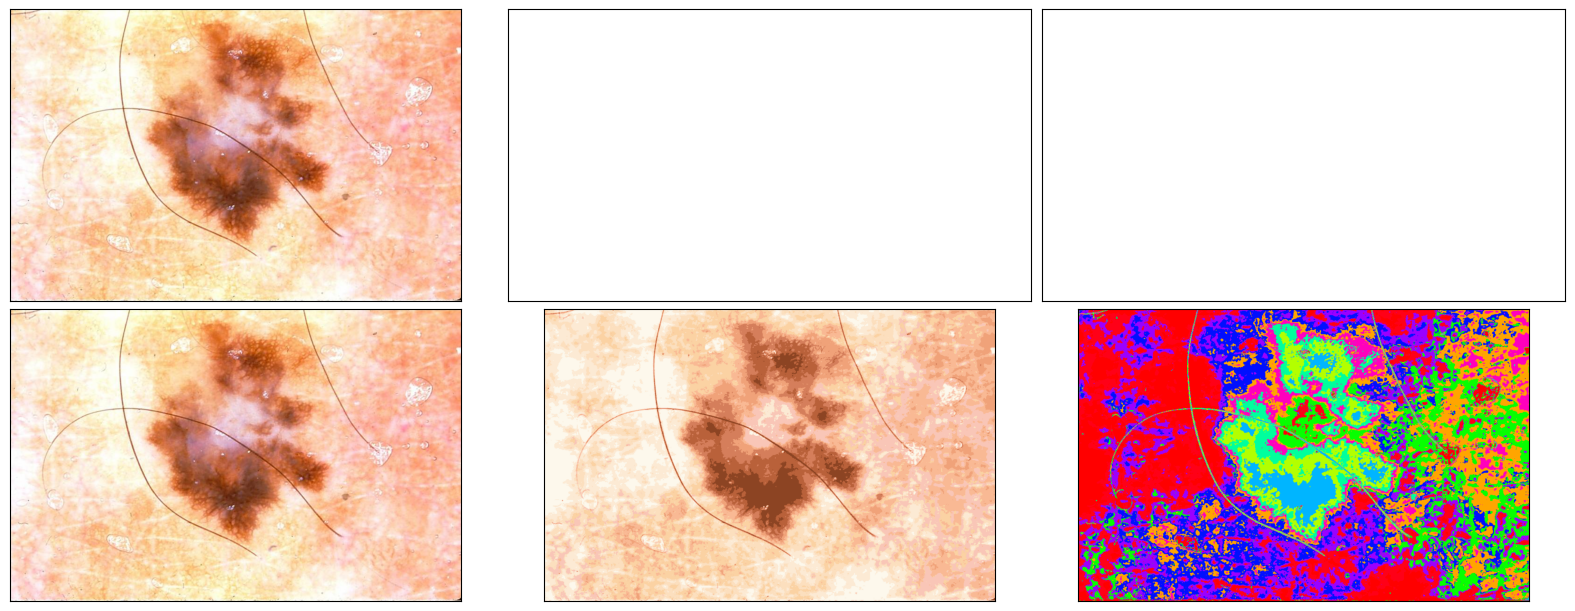

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 3, figsize=(16,6), layout='constrained')

ax1[0].imshow(RGBimg)
# ax1[1].imshow(raimbov)
# ax1[2].imshow(kmeans.labels_.reshape(img.shape[:-1]), cmap='hsv')

ax2[0].imshow(RGBimg)
ax2[1].imshow(Rraimbov)
ax2[2].imshow(Rkmeans.labels_.reshape(img.shape[:-1]), cmap='hsv')
for ax in np.concat((ax1, ax2)):
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

ValueError: cannot reshape array of size 783874 into shape (767,1022,3)

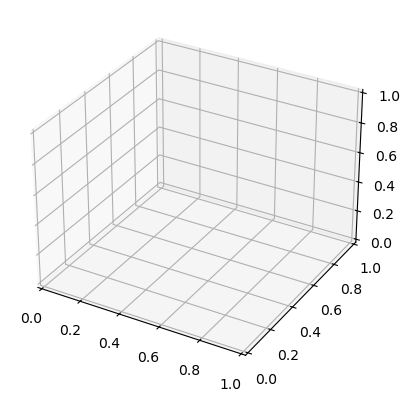

In [36]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(img[:,0], img[:,1], img[:,2], c=kmeans.labels_.reshape(img.shape))
plt.show()

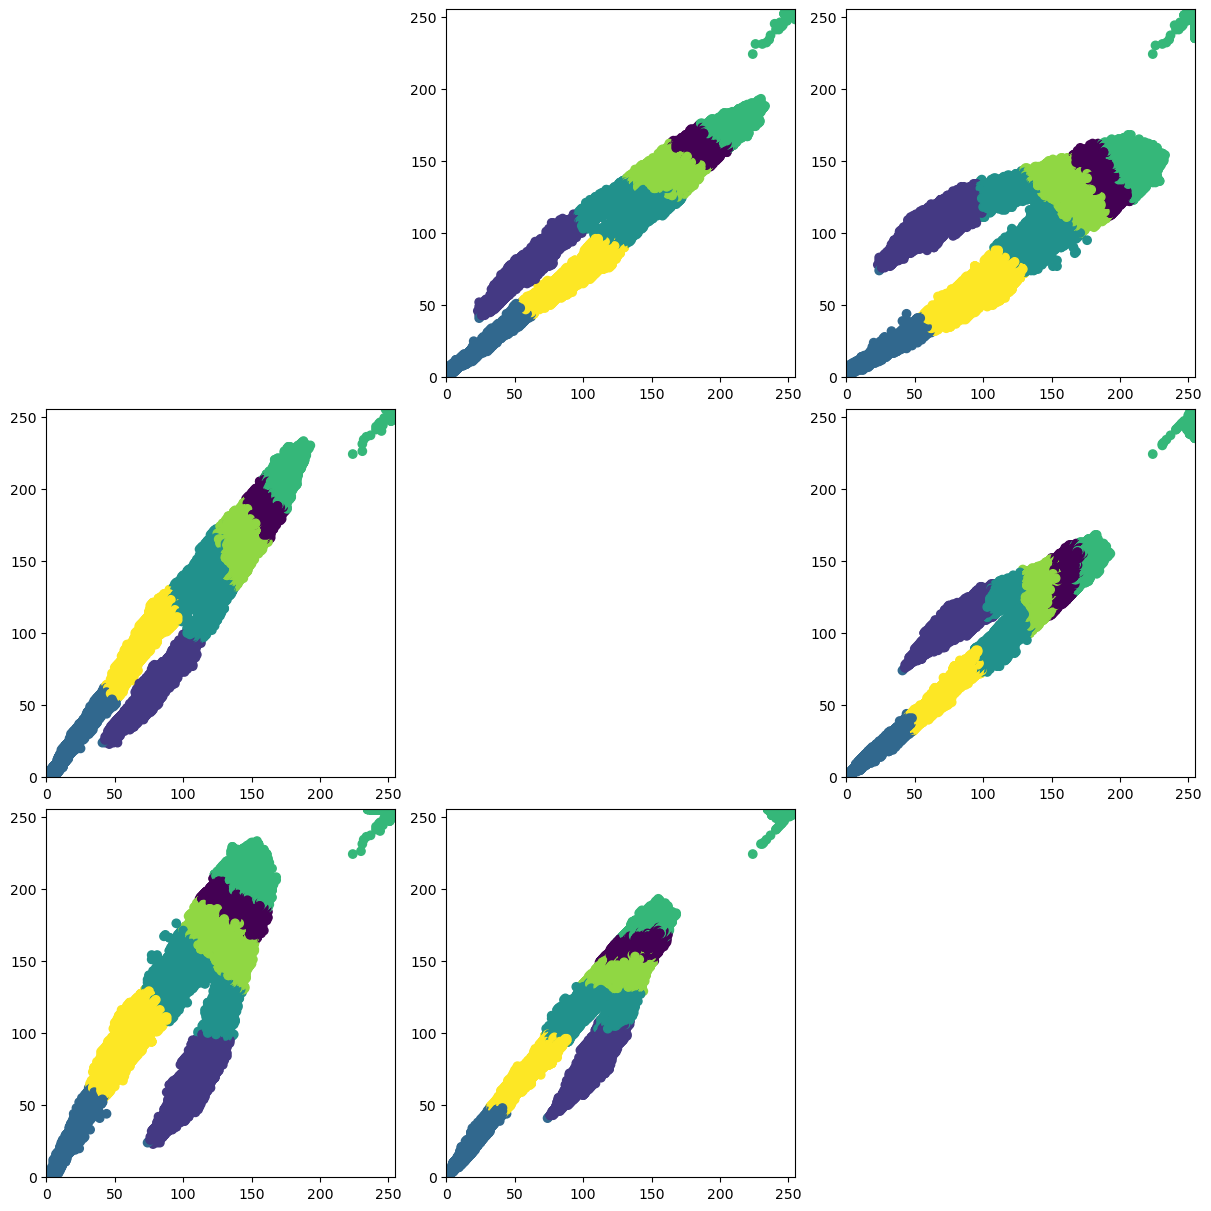

In [16]:
fig, ax = plt.subplots(3, 3, layout='constrained', figsize=(12,12))
for i in range(3):
    for j in range(3):
        if i == j: ax[i,j].remove()
        ax[i, j].scatter(img[..., i], img[..., j], c=kmeans.labels_)
        ax[i, j].set_xlim(0,255)
        ax[i, j].set_ylim(0,255)
plt.show()